# Parcial N°2 - Analisis de Datos COM3

### Integrantes:
* Pablo Vivas
* Lisandro Romero
* Tobias Rivas
* Morgui Mateo
* Diaz Manuel
* Diaz Sebastian

# Preguntas
* Qué tipos de automotores fueron los más transferidos en enero de 2025?
* ¿Qué marcas registraron la mayor cantidad de transferencias?
* En qué provincias se concentraron más transferencias?
* ¿Qué marcas lideran en cada provincia?
* ¿Qué tipo de automotor predomina según la provincia?
* persona juridica y personas fisicas

In [43]:
## Importacion de archivo csv
import pandas as pd
import numpy as np

df_csv_original = pd.read_csv('tranferencias_autos.csv')







cantidad_de_datos_duplicados= df_csv_original.duplicated().sum()

cantidad_de_datos_nulos = df_csv_original.isnull().sum()

print("-----DATOS DUPLICADOS-----")
print(cantidad_de_datos_duplicados)
print("")
print("-----DATOS NULOS-----")
display(cantidad_de_datos_nulos)
print("")
print("-----REVISAR DTYPE EN LA COLUMNA titular_anio_nacimiento-----")
# Revisamos el error que nos menciono y se detectan dos tipos (int y str)
print(df_csv_original['titular_anio_nacimiento'].apply(type).value_counts())
print("")
print("-----DATOS UNICOS EN LA COLUMNA automotor_tipo_descripcion ANTES DE LA CORRECCION-----")
# Se detectaron muchos datos unicos que rempresentan a un unico modelo 
# pero que pueden arruinar los graficos si se quiere sacar un numero completo del modelo
display(df_csv_original['automotor_tipo_descripcion'].unique())
print("")
print("-----DATOS UNICOS EN LA COLUMNA automotor_marca_descripcion ANTES DE LA CORRECCION-----")
# Se detectaron muchos datos unicos que rempresentan a una misma marca 
# pero que pueden arruinar los graficos si se quiere sacar un numero completo de la marca
display(df_csv_original['automotor_marca_descripcion'].unique())


C:\Users\elviv\AppData\Local\Temp\ipykernel_18848\111997410.py:5: DtypeWarning: Columns (0: titular_anio_nacimiento) have mixed types. Specify dtype option on import or set low_memory=False.
  df_csv_original = pd.read_csv('tranferencias_autos.csv')


-----DATOS DUPLICADOS-----
338

-----DATOS NULOS-----


tramite_tipo                         0
tramite_fecha                        0
fecha_inscripcion_inicial            0
registro_seccional_codigo            0
registro_seccional_descripcion      44
registro_seccional_provincia        44
automotor_origen                     0
automotor_anio_modelo              794
automotor_tipo_codigo             3797
automotor_tipo_descripcion           0
automotor_marca_codigo            1266
automotor_marca_descripcion          0
automotor_modelo_codigo           2184
automotor_modelo_descripcion         0
automotor_uso_codigo                 6
automotor_uso_descripcion            6
titular_tipo_persona                 0
titular_domicilio_localidad          6
titular_domicilio_provincia          0
titular_genero                       0
titular_anio_nacimiento              0
titular_pais_nacimiento              0
titular_porcentaje_titularidad       0
titular_domicilio_provincia_id       0
titular_pais_nacimiento_id        9612
dtype: int64


-----REVISAR DTYPE EN LA COLUMNA titular_anio_nacimiento-----
titular_anio_nacimiento
<class 'str'>    163840
<class 'int'>      6265
Name: count, dtype: int64

-----DATOS UNICOS EN LA COLUMNA automotor_tipo_descripcion ANTES DE LA CORRECCION-----


<StringArray>
[                   'PICK-UP',            'SEDAN 4 PUERTAS',
                    'PICK UP',       'TRANSP. DE PASAJEROS',
                     'FURGON',            'SEDAN 5 PUERTAS',
            'RURAL 5 PUERTAS',               'SEDAN 5 PTAS',
            'SEDAN 3 PUERTAS',            'SEDAN 2 PUERTAS',
 ...
       '17 - SEDAN 5 PUERTAS',   'SEDAN 4 ÙERTAS17/02/1977',
 'CHASIS C/ CABINA P/ CAMION',                'FRONTAL 4X4',
        'PICK-UP CAB. Y MED.',       'CARROZADO C/CAMIONET',
       'PICK-UP-DOBLE CABINA',           'SEDAN  5 PUERTAS',
                      'ARAUS',              'BUGGI PLAYERO']
Length: 995, dtype: str


-----DATOS UNICOS EN LA COLUMNA automotor_marca_descripcion ANTES DE LA CORRECCION-----


<StringArray>
[                          'FORD',                         'TOYOTA',
                     'VOLKSWAGEN',                      'CHEVROLET',
                            'KIA',                        'RENAULT',
                          'HONDA',                           'FIAT',
                          'STAHL',                           'AUDI',
 ...
                 'TANQUES ALVEAR',                        'ARDANAZ',
                      'CHRVROLET',                     'FIAT (044)',
                         'ARMADO',                 'FIAT INNOCENTI',
 'GMC CHEVETTE (GENERAL MOTORS C',                        'ZANELLO',
                      'DODGE GTX',                         'HYNDAI']
Length: 473, dtype: str

In [44]:
print("-----LIMPIAZA DE DATOS-----")
df_csv_filtrado = df_csv_original.drop_duplicates()

print("Cantidad de filas despues de la purga de datos duplicados:", len(df_csv_filtrado))

print("")
print("")


print("Se investigo y descubrio que los datos nullos de las columnas registro_seccional_descripcion")
print("y registro_seccional_provincia pertenecen a Buenos Aires, Avellaneda nº7")

print("")
# Arreglo de seccion y provincia
df_csv_filtrado['registro_seccional_descripcion'] = df_csv_filtrado['registro_seccional_descripcion'].fillna('AVELLANEDA Nº7')
df_csv_filtrado['registro_seccional_provincia'] = df_csv_filtrado['registro_seccional_provincia'].fillna('Buenos Aires')

# Correccion sobre los datos del csv en la columna automotor_tipo_descripcion
# revisamos los datos unicos que representan al mismo tipo y los unificamos en uno solo
# creamos una especie de mapper para no estar haciendo un replace por cada dato ya que eran demaciados errores, maldecimos a los que escribieron esto de esa forma.
df_csv_filtrado['automotor_tipo_descripcion'] = df_csv_filtrado['automotor_tipo_descripcion'].astype(str).str.strip()
mapper_correcciones_tipos = {
    '18' : 'NO ESPECIFICADO',
    '18/20/TT L' : 'NO ESPECIFICADO',
    '1810' : 'NO ESPECIFICADO',
    '18032006' : 'NO ESPECIFICADO',
    '.' : 'NO ESPECIFICADO',

    '3 (TRES) PUERTAS' : '3 PUERTAS',
    '3PUERTAS' : '3 PUERTAS',
    '3 PTAS' : '3 PUERTAS',
    '3 PTAS.' : '3 PUERTAS',
    '4 (CUATRO) PUERTAS' : '4 PUERTAS',
    '5 PTAS' : '5PUERTAS',
    '5 PTAS.' : '5PUERTAS',

    'ACOPALDO' : 'ACOPLADO',
    'ACOPLADO ACOPLADO BDAS VOLC.' : 'ACOPLADO ACOPLADO BDAS. VOLC.',
    'ACOPLADO ACOPLADO BDAS.VOLC.' : 'ACOPLADO ACOPLADO BDAS. VOLC.',
    'ACOPLADO BASE METALI' : 'ACOPLADO BASE METALICA',
    'ACOPLADO CARGA GENER' : 'ACOPLADO CARGA GENERAL',

    'AUTOMÓVIL' : 'AUTOMOVIL',
    'AUTOMOVIL (VOITURETT' : 'AUTOMOVIL',
    'AUTOMOVIL 4 PTAS' : 'AUTOMOVIL 4 PUERTAS',
    'AUTOMOVIL DE PASAJER' : 'AUTOMOVIL DE PASAJEROS',

    'BARLINA 5 PTAS.' : 'BERLINA 5 PUERTAS',
    'BERLIN 5 PUERTAS.' : 'BERLINA 5 PUERTAS',
    'BERLINA  5 PUERTAS.' : 'BERLINA 5 PUERTAS',
    'BERLINA 5  PTAS' : 'BERLINA 5 PUERTAS',
    'BERLINA 5 PTAS' : 'BERLINA 5 PUERTAS',
    'BERLINA 5 PTAS.' : 'BERLINA 5 PUERTAS',
    'BERLINA 5 PTAS.-' : 'BERLINA 5 PUERTAS',
    'BERLINA 5 PTS.' : 'BERLINA 5 PUERTAS',
    'BERLINA 5 PTSA' : 'BERLINA 5 PUERTAS',
    'BERLINA 5P' : 'BERLINA 5 PUERTAS',
    'BERLINA 5PTAS' : 'BERLINA 5 PUERTAS',
    'BERLINA  3PTAS' : 'BERLINA 3 PUERTAS',
    'BERLINA 3PTAS.' : 'BERLINA 3 PUERTAS',
    'BERLINA 3TAS.AA' : 'BERLINA 3 PUERTAS',
    'BERLINA 3 PTAS' : 'BERLINA 3 PUERTAS',
    'BERLINA 3 PTAS.' : 'BERLINA 3 PUERTAS',
    'BERLINA 3 PTAS.AA' : 'BERLINA 3 PUERTAS',
    'BERLINA 3 PT AA' : 'BERLINA 3 PUERTAS',
    'BERLINA 3 PT.AA' : 'BERLINA 3 PUERTAS',
    'BERLINA 3PT.AA' : 'BERLINA 3 PUERTAS',
    'BERLINA 3PT AA' : 'BERLINA 3 PUERTAS',
    'BERLINA 3 PUERTAS. AA' : 'BERLINA 3 PUERTAS',
    'BERLINA 3 PUERTAS AA' : 'BERLINA 3 PUERTAS',
    'BERLINA  4 PTAS.' : 'BERLINA 4 PUERTAS',
    'BERLINA 4 PTAS.' : 'BERLINA 4 PUERTAS',
    'BERLINA 4 PTAS' : 'BERLINA 4 PUERTAS',
    'BERLINA 4PTAS.' : 'BERLINA 4 PUERTAS',
    'BERLINA 4PTAS' : 'BERLINA 4 PUERTAS',
    'BERLINA 2 PTAS' : 'BERLINA 2 PUERTAS',
    'BERLINA 2 PTAS.' : 'BERLINA 2 PUERTAS',

    'CASA RODANTE C/ MOTOR' : 'CASA RODANTE C/MOTOR',
    'CASA RODANTE MOTORIZADA' : 'CASA RODANTE C/MOTOR',
    'CASA RODANTE CON MOTOR' : 'CASA RODANTE C/MOTOR',

    'CHASIS C/ CABINA' : 'CHASIS C/CABINA',
    'CHASIS  C/CABINA' : 'CHASIS C/CABINA',
    'CHASSIS C/ CABINA' : 'CHASIS C/CABINA',
    'CHASSIS C/CABINA' : 'CHASIS C/CABINA',
    'CHASIS CON CABINA' : 'CHASIS C/CABINA',
    'CHASSIS CON CABINA' : 'CHASIS C/CABINA',
    'CHASSIS CABINADO' : 'CHASIS C/CABINA',
    'CHASIS SIN CABINA' : 'CHASIS S/CABINA',
    'CHASIS C/ CABINA DOR' : 'CHASIS C/CABINA DORMITORIO',
    'CHASIS C/ CABINA DORMITORIO' : 'CHASIS C/CABINA DORMITORIO',

    'CONVERTIBLE 2 PTAS' : 'CONVERTIBLE 2 PUERTAS',
    'CONVERTIBLE 2 PTAS.' : 'CONVERTIBLE 2 PUERTAS',
    'CONVERTIBLE 2 PUERTA' : 'CONVERTIBLE 2 PUERTAS',

    '1500 COUPE' : 'COUPE',
    '2 PUERTAS COUPE' : 'COUPE 2 PUERTAS',
    'COUPE  2 PTAS' : 'COUPE 2 PUERTAS',
    'COUPE 2 PTAS' : 'COUPE 2 PUERTAS',
    'COUPE 2 PTAS.' : 'COUPE 2 PUERTAS',
    'COUPE 2 PTS' : 'COUPE 2 PUERTAS',
    'COUPE 2 PÙERTAS' : 'COUPE 2 PUERTAS',
    'COUPE 3 PTAS' : 'COUPE 3 PUERTAS',
    'COUPE 3 PTAS.' : 'COUPE 3 PUERTAS',

    'DEPORTIVO 3 PTAS' : 'DEPORTIVO 3 PUERTAS',
    'DEPORTIVO 3 P' : 'DEPORTIVO 3 PUERTAS',

    'MICROOMNIBUS' : 'MICRO OMNIBUS',
    'MICROOMNIUS' : 'MICRO OMNIBUS',

    '11 PICK UP' : 'PICK-UP',
    '22- PICK UP' : 'PICK-UP',
    'PICK - UP' : 'PICK-UP',
    'PICKUP' : 'PICK-UP',
    'PICK NUP' : 'PICK-UP',
    'PICK UP' : 'PICK-UP',
    'PICK -UP' : 'PICK-UP',
    'PICK- UP' : 'PICK-UP',
    'PICK UP 2 PUERTAS' : 'PICK-UP 2 PUERTAS',
    'PICK UP 2 PTAS' : 'PICK-UP 2 PUERTAS',
    'PICK UP 2 PTAS.' : 'PICK-UP 2 PUERTAS',
    'PICK-UP 2 PTAS' : 'PICK-UP 2 PUERTAS',
    'PICK-UP CABINA Y MED' : 'PICK-UP CABINA Y MEDIA',
    'PICK- UP CABINA Y MEDIA' : 'PICK-UP CABINA Y MEDIA',
    'PICK UP CBINA DOBLE' : 'PICK-UP CABINA DOBLE',
    'PICK UP CABINA DOBLE' : 'PICK-UP CABINA DOBLE',
    'PICK UP DOBLE CABINA' : 'PICK-UP CABINA DOBLE',

    'RURAL 2 PTAS.-' : 'RURAL 2 PUERTAS',
    'RURAL 2/3 PTAS' : 'RURAL 2/3 PUERTAS',
    'RURAL 3 PTAS' : 'RURAL 3 PUERTAS',
    'RURAL 3/4 PTAS' : 'RURAL 3/4 PUERTAS',
    'RURAL 4  PTAS' : 'RURAL 4 PUERTAS',
    'RURAL 4  PUERTAS' : 'RURAL 4 PUERTAS',
    'RURAL 4 PTAS' : 'RURAL 4 PUERTAS',
    'RURAL 4/ 5 PUERTAS' : 'RURAL 4/5 PUERTAS',
    'RURAL 4/5 PTAS' : 'RURAL 4/5 PUERTAS',
    'RURAL 5 P' : 'RURAL 5 PUERTAS',
    'RURAL 5 PIERTAS' : 'RURAL 5 PUERTAS',
    'RURAL 5 PTAS' : 'RURAL 5 PUERTAS',
    'RURAL 5 PTS' : 'RURAL 5 PUERTAS',
    'RURAL 5 PU ERTAS' : 'RURAL 5 PUERTAS',
    'RURAL 5PUERTAS' : 'RURAL 5 PUERTAS',

    'SED' : 'SEDAN',
    'SEDAN 2  PTAS' : 'SEDAN 2 PUERTAS',
    'SEDAN 2 P`TAS' : 'SEDAN 2 PUERTAS',
    'SEDAN 2 PTAS' : 'SEDAN 2 PUERTAS',
    'SEDAN 2 PTAS.' : 'SEDAN 2 PUERTAS',
    'SEDAN 2PUERTAS' : 'SEDAN 2 PUERTAS',
    '22 - SEDAN 3 PUERTAS' : 'SEDAN 3 PUERTAS',
    'SEDAN  3 PUERTAS' : 'SEDAN 3 PUERTAS',
    'SEDAN 3 P' : 'SEDAN 3 PUERTAS',
    'SEDAN 3 PTAS' : 'SEDAN 3 PUERTAS',
    'SEDAN 3 PTAS.' : 'SEDAN 3 PUERTAS',
    'SEDAN 3 PTS' : 'SEDAN 3 PUERTAS',
    'SEDAN 3 PUER' : 'SEDAN 3 PUERTAS',
    'SEDAN 3 PURTAS' : 'SEDAN 3 PUERTAS',
    'SEDAN 3P' : 'SEDAN 3 PUERTAS',
    'SEDAN 3PTAS' : 'SEDAN 3 PUERTAS',
    'SEDAN 3PTS' : 'SEDAN 3 PUERTAS',
    'SEDAN 3PUERTAS' : 'SEDAN 3 PUERTAS',
    '12 - SEDAN 4 PUERTAS' : 'SEDAN 4 PUERTAS',
    'SEDAN  4 PTAS' : 'SEDAN 4 PUERTAS',
    'SEDAN  4 PUERTAS' : 'SEDAN 4 PUERTAS',
    'SEDAB 4 PUERTAS' : 'SEDAN 4 PUERTAS',
    'SED. 4 PTAS' : 'SEDAN 4 PUERTAS',
    'SEDAN 4' : 'SEDAN 4 PUERTAS',
    'SEDAN 4  PUERTAS' : 'SEDAN 4 PUERTAS',
    'SEDAN 4 P' : 'SEDAN 4 PUERTAS',
    'SEDAN 4 POERTAS' : 'SEDAN 4 PUERTAS',
    'SEDAN 4 PTAS' : 'SEDAN 4 PUERTAS',
    'SEDAN 4 PTAS.' : 'SEDAN 4 PUERTAS',
    'SEDAN 4 PTS' : 'SEDAN 4 PUERTAS',
    'SEDAN 4 PTUERAS' : 'SEDAN 4 PUERTAS',
    'SEDAN 4 PUERAS' : 'SEDAN 4 PUERTAS',
    'SEDAN 4 PURTAS' : 'SEDAN 4 PUERTAS',
    'SEDAN 4 ÙERTAS17/02/1977' : 'SEDAN 4 PUERTAS',
    'SEDAN 4P' : 'SEDAN 4 PUERTAS',
    'SEDAN 4P BASE 1.6N' : 'SEDAN 4 PUERTAS',
    'SEDAN 4PTS' : 'SEDAN 4 PUERTAS',
    'SEDAN CUATRO PUERTAS' : 'SEDAN 4 PUERTAS',
    'SEDSN 4 PUERTA' : 'SEDAN 4 PUERTAS',
    '12- SEDAN 5 PUERTAS' : 'SEDAN 5 PUERTAS',
    '17 - SEDAN 5 PUERTAS' : 'SEDAN 5 PUERTAS',
    'SEDAN  5 PUERTAS' : 'SEDAN 5 PUERTAS',
    'SEDAN  5 PTAS' : 'SEDAN 5 PUERTAS',
    'SEDAN 5 P' : 'SEDAN 5 PUERTAS',
    'SEDAN 5 P.' : 'SEDAN 5 PUERTAS',
    'SEDAN 5 PTAS' : 'SEDAN 5 PUERTAS',
    'SEDAN 5 PTAS.' : 'SEDAN 5 PUERTAS',
    'SEDAN 5 PTAS.-' : 'SEDAN 5 PUERTAS',
    'SEDAN 5 PTS' : 'SEDAN 5 PUERTAS',
    'SEDAN 5P' : 'SEDAN 5 PUERTAS',
    'SEDAN 5PUERTAS' : 'SEDAN 5 PUERTAS',

    'SEMI-ACOPLADO' : 'SEMIACOPLADO',
}
df_csv_filtrado['automotor_tipo_descripcion'] = df_csv_filtrado['automotor_tipo_descripcion'].replace(mapper_correcciones_tipos)


# Correccion sobre los datos del csv en la columna automotor_marca_descripcion
# revisamos los datos unicos que representan a la misma marca y los unificamos en uno solo (incluyendo los colectivos que tienen la marca con /MARCOPOLO al final)
# creamos una especie de mapper para no estar haciendo un replace por cada dato ya que eran demaciados errores, volvemos a maldecir a los que escribieron esto de esa forma.
df_csv_filtrado['automotor_marca_descripcion'] = df_csv_filtrado['automotor_marca_descripcion'].astype(str).str.strip()
mapper_correcciones_marcas = {
    'A.F.F' : 'ARMADO FUERA DE FABRICA',
    'AFF' : 'ARMADO FUERA DE FABRICA',
    'A.F.F.' : 'ARMADO FUERA DE FABRICA',

    'ASTIVIA S.A.' : 'ASTIVIA',

    'B M W' : 'BMW',

    '|CHEVROLET' : 'CHEVROLET',
    'AHEVROLET' : 'CHEVROLET',
    'CEHVROLET' : 'CHEVROLET',
    'CHEVROLET (024)' : 'CHEVROLET',
    'CHEVROLET CAMARO' : 'CHEVROLET',
    'CHEVROLET CAPRICE' : 'CHEVROLET',
    'CHEVROLÑET' : 'CHEVROLET',
    'CHEVRPLET' : 'CHEVROLET',
    'CHVROLET' : 'CHEVROLET',
    'CHRVROLET' : 'CHEVROLET',
    'R.L.   CHEVROLET' : 'CHEVROLET',

    'CRHYSLER' : 'CHRYSLER',
    'CHRYSLER DODGE' : 'CHRYSLER-DODGE',

    'CITREON' : 'CITROEN',
    'CITROËN' : 'CITROEN',

    '-031-DAEWOO' : 'DAEWOO',
    '-031- DAEWOO' : 'DAEWOO',

    'DEUTZ AGRALE' : 'DEUTZ - AGRALE',

    '15 - DODGE' : 'DODGE',
    'DODGE CORONADO' : 'DODGE',
    'DODGE GTX' : 'DODGE',
    'DODGE M601' : 'DODGE',

    'F.H' : 'F.H.',
    'F Y H' : 'F.H.',

    '-044-FIAT' : 'FIAT',
    '17-FIAT' : 'FIAT',
    'FÍAT' : 'FIAT',
    'FIAT (044)' : 'FIAT',
    'FIAT CONCORD SAIC' : 'FIAT',
    'FIAT INNOCENTI' : 'FIAT',
    'FIAT.' : 'FIAT',

    'FORD A' : 'FORD',
    'FORD ARGENTINA S.A.' : 'FORD',
    'FORD F 600' : 'FORD',
    'FORD FALCON' : 'FORD',
    'FORD PREFECT' : 'FORD',
    'FORD VAN STANDARD' : 'FORD',
    'FORD.' : 'FORD',
    'FORD-MUSTANG-GHIA' : 'FORD',

    'GENERAL MOTORS' : 'GMC',
    'GMC (CHEVETTE)' : 'GMC',
    'GMC CHEVETTE' : 'GMC',
    'GMC CHEVETTE (GENERAL MOTORS C' : 'GMC',
    'GMC CHEVETTE (GENERAL MOTORS CORPORATION)' : 'GMC',

    '-055-HONDA' : 'HONDA',

    'HYNDAI' : 'HYUNDAI',

    'I.E.S.' : 'IES',

    'I.K.A.' : 'IKA',
    'IKA BAQUEANO' : 'IKA',
    'IKA ESTANCIERA' : 'IKA',
    'IKA-ESTANCIERA' : 'IKA',
    'IKA RENAULT 850' : 'IKA',
    'IKA-RENAULT' : 'IKA',
    'IKA TORINO' : 'IKA',
    'IKA-TORINO S' : 'IKA',

    'IVECO-MAGIRUS' : 'IVECO',

    'JEEP ESTANCIERA' : 'JEEP',
    'JEEP FRONTAL' : 'JEEP',
    'JEEP GLADIADOR V SUPER' : 'JEEP',
    'JEEP GLADIATOR' : 'JEEP',
    'JEEP GLADIATOR V SUPER' : 'JEEP',
    'JEEP GLADIATOR X SUPER' : 'JEEP',
    'JEEP T-80' : 'JEEP',
    'JEEP WILLIS' : 'JEEP',
    'JEEP WILLYS' : 'JEEP',

    'JEEP I.K.A.' : 'JEEP IKA',
    'JEEP IKA 1000' : 'JEEP IKA',
    'JEEP-IKA' : 'JEEP IKA',

    'KAISER CARABELA' : 'KAISER',

    'K I A' : 'KIA',

    'LAND ROVER SANTANA' : 'LAND ROVER',

    'M BENZ' : 'MERCEDES BENZ',
    'M. BENZ' : 'MERCEDES BENZ',
    'M.BENZ' : 'MERCEDES BENZ',
    'MERCEDES BENZ/COMIL' : 'MERCEDES BENZ',
    'MERCEDES BENZ/M' : 'MERCEDES BENZ',
    'MERCEDES BENZ/MARCOPOLO' : 'MERCEDES BENZ',
    'MERCEDES-BENZ' : 'MERCEDES BENZ',
    'MERCEDEZ BENZ' : 'MERCEDES BENZ',
    'MERCEDEZ-BENZ' : 'MERCEDES BENZ',

    'MITSUBISH' : 'MITSUBISHI',
    'MITSUBUSHI' : 'MITSUBISHI',

    'PEUGEOT (010)' : 'PEUGEOT',
    'PEUGEOT (104)' : 'PEUGEOT',

    'PRATI' : 'PRATI-FRUEHAUF',
    'PRATI FRUEHAUF' : 'PRATI-FRUEHAUF',
    'PRATI- FRUEHAUF' : 'PRATI-FRUEHAUF',
    'PRATTI' : 'PRATI-FRUEHAUF',
    'PRATTI-FRUEHAUF' : 'PRATI-FRUEHAUF',

    'RSATROJERO DIESEL' : 'RASTROJERO DIESEL',

    '.RENAULT' : 'RENAULT',
    '-112- RENAULT' : 'RENAULT',
    '-112-RENAULT' : 'RENAULT',
    'RENAULT 4-L' : 'RENAULT',
    'RENAULT.' : 'RENAULT',
    'RENAUT' : 'RENAULT',
    'RENAUTL' : 'RENAULT',
    'RENUALT' : 'RENAULT',

    'SCANIA' : 'SCANIA',
    'SCANIA VABIS' : 'SCANIA',
    'SCANIA-VABIS' : 'SCANIA',
    'SCANIA/COMIL' : 'SCANIA',
    'SCANIA/MARCOPOLO' : 'SCANIA',

    '-127-SUZUKI' : 'SUZUKI',
    'SUZUKI CARRY' : 'SUZUKI',
    'SUZUKI SUPER CARRY' : 'SUZUKI',
    'SUZUKI SWIFT' : 'SUZUKI',
    'SUZUKI SWIFT GT' : 'SUZUKI',
    'SUZUKI SWIFT GTI' : 'SUZUKI',
    'SUZUKI SWIFT SEDAN NL' : 'SUZUKI',
    'SUZUKI SWIFT SEDAN NLX' : 'SUZUKI',
    'SUZUKI VITARA' : 'SUZUKI',

    '}TOYOTA' : 'TOYOTA',
    '-130-TOYOTA' : 'TOYOTA',
    'T O Y O T A' : 'TOYOTA',
    'TOYOTA                TOYOTA' : 'TOYOTA',

    '136 VOLKSWAGEN' : 'VOLKSWAGEN',
    '-136-VOLKSWAGEN' : 'VOLKSWAGEN',
    'VILKSWAGEN' : 'VOLKSWAGEN',
    'VOKLKSWAGEN' : 'VOLKSWAGEN',
    'VOKSWAGEN' : 'VOLKSWAGEN',
    'VOLKSWAGEN (136)' : 'VOLKSWAGEN',
    'VOLKSWAGEN ARGENTINA SA' : 'VOLKSWAGEN',
    'VOLKWAGEN' : 'VOLKSWAGEN',
    'VOLSKSWAGEN' : 'VOLKSWAGEN',
    'VOLSKWAGEN' : 'VOLKSWAGEN',
    'VOLSKWAGEN (034)' : 'VOLKSWAGEN',
    'VOLSWAGEN' : 'VOLKSWAGEN',
    'WOLKSWAGEN' : 'VOLKSWAGEN',

    'VOLVO/MARCOPOLO' : 'VOLVO',

    'WILLYS -IKA' : 'WILLYS',
    'WILLYS OVE' : 'WILLYS',
    'WYLLIS' : 'WILLYS',
}
df_csv_filtrado['automotor_marca_descripcion'] = df_csv_filtrado['automotor_marca_descripcion'].replace(mapper_correcciones_marcas)

# Arreglo de uso a no declarado como el resto 
df_csv_filtrado['automotor_uso_codigo'] = df_csv_filtrado['automotor_uso_codigo'].fillna(9)
df_csv_filtrado['automotor_uso_descripcion'] = df_csv_filtrado['automotor_uso_descripcion'].fillna('No declarado')

# Rellenado de datos nulos
df_csv_filtrado['automotor_anio_modelo'] = df_csv_filtrado['automotor_anio_modelo'].fillna('No especificado')
df_csv_filtrado['automotor_tipo_codigo'] = df_csv_filtrado['automotor_tipo_codigo'].fillna('No especificado')
df_csv_filtrado['automotor_marca_codigo'] = df_csv_filtrado['automotor_marca_codigo'].fillna('No especificado')
df_csv_filtrado['automotor_modelo_codigo'] = df_csv_filtrado['automotor_modelo_codigo'].fillna('No especificado')
df_csv_filtrado['titular_domicilio_localidad'] = df_csv_filtrado['titular_domicilio_localidad'].fillna('-')
df_csv_filtrado['titular_pais_nacimiento_id'] = df_csv_filtrado['titular_pais_nacimiento_id'].fillna('No especificado')

# Correccion sobre el dtype en la columna titular_anio_nacimiento.
# Resulta que por culpa de datos nulos en el csv a partir de la siguiente fila despues del primer nulo
# los numeros pasan a ser string, generado que hayan 2 tipos de datos (int y str).

df_csv_filtrado['titular_anio_nacimiento'] = df_csv_filtrado['titular_anio_nacimiento'].astype(str).str.strip()
df_csv_filtrado['titular_anio_nacimiento'] = df_csv_filtrado['titular_anio_nacimiento'].replace('', np.nan)
df_csv_filtrado['titular_anio_nacimiento'] = pd.to_numeric(df_csv_filtrado['titular_anio_nacimiento'], errors='coerce').astype('Int64')

print("VERIFICACION DE CAMBIO DE DTYPE AHORA CORRECTO EN LA COLUMNA titular_anio_nacimiento")
print(df_csv_filtrado['titular_anio_nacimiento'].dtype)
print(df_csv_filtrado['titular_anio_nacimiento'].apply(type).value_counts())

print("")
print("-----DATOS UNICOS EN LA COLUMNA automotor_tipo_descripcion DESPUES DE LA CORRECCION-----")
display(df_csv_filtrado['automotor_tipo_descripcion'].unique())
print("")
print("-----DATOS UNICOS EN LA COLUMNA automotor_marca_descripcion DESPUES DE LA CORRECCION-----")
display(df_csv_filtrado['automotor_marca_descripcion'].unique())

print("")
# Arreglo de datos nulos en la columna titular_anio_nacimiento
# elegimos hacer algo que a lo mejor no se tan buena idea pero es un tipo de dato un poco irrelebante para el analisis
# ya que el analisis esta enfocado en las marcas y modelos de vehiculos, tomando como mucho el genero o tipo de persona, no su año de nacimiento.
# Rellenaremos esos campos nulos con la media de todas las edades, es mejor que eliminarlos directamente.
df_csv_filtrado['titular_anio_nacimiento'] = df_csv_filtrado['titular_anio_nacimiento'].fillna(df_csv_filtrado['titular_anio_nacimiento'].median())

print("")

print("Conteo de nulos por columna despues del arreglo:")
display(df_csv_filtrado.isnull().sum())




-----LIMPIAZA DE DATOS-----
Cantidad de filas despues de la purga de datos duplicados: 169767


Se investigo y descubrio que los datos nullos de las columnas registro_seccional_descripcion
y registro_seccional_provincia pertenecen a Buenos Aires, Avellaneda nº7

VERIFICACION DE CAMBIO DE DTYPE AHORA CORRECTO EN LA COLUMNA titular_anio_nacimiento
Int64
titular_anio_nacimiento
<class 'float'>    169767
Name: count, dtype: int64

-----DATOS UNICOS EN LA COLUMNA automotor_tipo_descripcion DESPUES DE LA CORRECCION-----


<StringArray>
[                     'PICK-UP',              'SEDAN 4 PUERTAS',
         'TRANSP. DE PASAJEROS',                       'FURGON',
              'SEDAN 5 PUERTAS',              'RURAL 5 PUERTAS',
              'SEDAN 3 PUERTAS',              'SEDAN 2 PUERTAS',
         'PICK-UP CABINA DOBLE',                'SEMIRREMOLQUE',
 ...
   'CAJA ABIERTA CON HIDROGRUA',   'FURGON VIDRIADO CON ASIENT',
 'SEMIRREMOLQUEVOLCADOR1+2EJES',   'CHASIS C/ CABINA P/ CAMION',
                  'FRONTAL 4X4',          'PICK-UP CAB. Y MED.',
         'CARROZADO C/CAMIONET',         'PICK-UP-DOBLE CABINA',
                        'ARAUS',                'BUGGI PLAYERO']
Length: 839, dtype: str


-----DATOS UNICOS EN LA COLUMNA automotor_marca_descripcion DESPUES DE LA CORRECCION-----


<StringArray>
[          'FORD',         'TOYOTA',     'VOLKSWAGEN',      'CHEVROLET',
            'KIA',        'RENAULT',          'HONDA',           'FIAT',
          'STAHL',           'AUDI',
 ...
        'SHACMAN',     'AGROCABINA',          'KAMAZ',          'RUGBY',
       'ROS ROCA',      'EL GRANDE', 'TANQUES ALVEAR',        'ARDANAZ',
         'ARMADO',        'ZANELLO']
Length: 338, dtype: str



Conteo de nulos por columna despues del arreglo:


tramite_tipo                      0
tramite_fecha                     0
fecha_inscripcion_inicial         0
registro_seccional_codigo         0
registro_seccional_descripcion    0
registro_seccional_provincia      0
automotor_origen                  0
automotor_anio_modelo             0
automotor_tipo_codigo             0
automotor_tipo_descripcion        0
automotor_marca_codigo            0
automotor_marca_descripcion       0
automotor_modelo_codigo           0
automotor_modelo_descripcion      0
automotor_uso_codigo              0
automotor_uso_descripcion         0
titular_tipo_persona              0
titular_domicilio_localidad       0
titular_domicilio_provincia       0
titular_genero                    0
titular_anio_nacimiento           0
titular_pais_nacimiento           0
titular_porcentaje_titularidad    0
titular_domicilio_provincia_id    0
titular_pais_nacimiento_id        0
dtype: int64

In [45]:
print("-----ELIMINACION DE OUTLIERS (METODO IQR)-----")
print("")

# Se aplica IQR sobre automotor_anio_modelo para detectar años imposibles o erroneos
# Se convierte a numerico porque la columna tiene valores 'No especificado' (strings)
anio_numerico = pd.to_numeric(df_csv_filtrado['automotor_anio_modelo'], errors='coerce')

Q1 = anio_numerico.quantile(0.25)
Q3 = anio_numerico.quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")
print(f"Limite inferior: {limite_inferior} | Limite superior: {limite_superior}")
print("")

registros_antes = len(df_csv_filtrado)

# Se conservan las filas con año dentro del rango valido o sin año declarado
mask_validos = anio_numerico.isna() | ((anio_numerico >= limite_inferior) & (anio_numerico <= limite_superior))
df_csv_filtrado = df_csv_filtrado[mask_validos]

registros_despues = len(df_csv_filtrado)
outliers_eliminados = registros_antes - registros_despues

print(f"Registros antes de eliminar outliers: {registros_antes}")
print(f"Registros despues de eliminar outliers: {registros_despues}")
print(f"Outliers eliminados: {outliers_eliminados}")

-----ELIMINACION DE OUTLIERS (METODO IQR)-----

Q1: 2007.0 | Q3: 2017.0 | IQR: 10.0
Limite inferior: 1992.0 | Limite superior: 2032.0

Registros antes de eliminar outliers: 169767
Registros despues de eliminar outliers: 162837
Outliers eliminados: 6930


In [46]:
print("-----FEATURE ENGINEERING-----")
print("")

# Antiguedad del vehiculo al momento de la transferencia
anio_numerico = pd.to_numeric(df_csv_filtrado['automotor_anio_modelo'], errors='coerce')
df_csv_filtrado['automotor_antiguedad'] = (2025 - anio_numerico).astype('Int64')

print("Nueva variable: automotor_antiguedad (años desde el modelo hasta 2025)")
print(df_csv_filtrado['automotor_antiguedad'].describe())
print("")

# Categoria de antiguedad basada en la variable anterior
def categorizar_antiguedad(anios):
    if pd.isna(anios):
        return 'No especificado'
    elif anios <= 5:
        return 'Casi nuevo (0-5 años)'
    elif anios <= 15:
        return 'Usado (6-15 años)'
    else:
        return 'Antiguo (+15 años)'

df_csv_filtrado['automotor_categoria_antiguedad'] = df_csv_filtrado['automotor_antiguedad'].apply(categorizar_antiguedad)

print("Nueva variable: automotor_categoria_antiguedad")
print(df_csv_filtrado['automotor_categoria_antiguedad'].value_counts())

-----FEATURE ENGINEERING-----

Nueva variable: automotor_antiguedad (años desde el modelo hasta 2025)
count     162045.0
mean     13.103175
std       7.323912
min            0.0
25%            8.0
50%           12.0
75%           17.0
max           33.0
Name: automotor_antiguedad, dtype: Float64

Nueva variable: automotor_categoria_antiguedad
automotor_categoria_antiguedad
Usado (6-15 años)        92537
Antiguo (+15 años)       48767
Casi nuevo (0-5 años)    20741
No especificado            792
Name: count, dtype: int64


In [47]:
print("-----SECCION DE PREGUNTAS DE NEGOCIO-----")

print("")
print("-----TIPOS DE AUTOMOTORES MAS TRANSFERIDOS-----")
df_cantidad_tipo = df_csv_filtrado['automotor_tipo_descripcion'].value_counts()
display(df_cantidad_tipo)

print("")
print("-----MARCAS CON MAYOR CANTIDAD DE TRANSFERENCIAS-----")
df_cantidad_marca = df_csv_filtrado['automotor_marca_descripcion'].value_counts()
display(df_cantidad_marca)

print("")
print("-----PROVINCIAS CON MAYOR CANTIDAD DE TRANSFERENCIAS-----")
df_cantidad_provincia = df_csv_filtrado['registro_seccional_provincia'].value_counts()
display(df_cantidad_provincia)

print("")
print("-----MARCAS DE AUTO QUE LIDERAN EN PROVINCIAS CON MAYOR CANTIDAD DE TRANSFERENCIAS-----")
cantidad_marca_provincia = df_csv_filtrado.groupby(['registro_seccional_provincia', 'automotor_marca_descripcion']).size().reset_index(name='cantidad_marca')
marcas = cantidad_marca_provincia.loc[cantidad_marca_provincia.groupby('registro_seccional_provincia')['cantidad_marca'].idxmax()]
display(marcas)

print("")
print("-----TIPO DE AUTO QUE LIDERAN EN PROVINCIAS CON MAYOR CANTIDAD DE TRANSFERENCIAS-----")
cantidad_tipo_provincia = df_csv_filtrado.groupby(['registro_seccional_provincia', 'automotor_tipo_descripcion']).size().reset_index(name='cantidad_modelo')
tipo = cantidad_tipo_provincia.loc[cantidad_tipo_provincia.groupby('registro_seccional_provincia')['cantidad_modelo'].idxmax()]
display(tipo)

print("")
print("-----TITULAR DEL VEHICULO, FISICA O JURIDICA-----")
df_titular = df_csv_filtrado['titular_tipo_persona'].value_counts()
display(df_titular)

-----SECCION DE PREGUNTAS DE NEGOCIO-----

-----TIPOS DE AUTOMOTORES MAS TRANSFERIDOS-----


automotor_tipo_descripcion
SEDAN 5 PUERTAS               55835
SEDAN 4 PUERTAS               34582
PICK-UP                       19078
SEDAN 3 PUERTAS               13321
RURAL 5 PUERTAS               12542
                              ...  
CHASIS C/ CABINA P/ CAMION        1
FRONTAL 4X4                       1
PICK-UP CAB. Y MED.               1
PICK-UP-DOBLE CABINA              1
BUGGI PLAYERO                     1
Name: count, Length: 678, dtype: int64


-----MARCAS CON MAYOR CANTIDAD DE TRANSFERENCIAS-----


automotor_marca_descripcion
VOLKSWAGEN        30263
FORD              21559
CHEVROLET         19258
RENAULT           18785
FIAT              16646
                  ...  
ROS ROCA              1
EL GRANDE             1
TANQUES ALVEAR        1
UAZ                   1
GORDINI IKA           1
Name: count, Length: 276, dtype: int64


-----PROVINCIAS CON MAYOR CANTIDAD DE TRANSFERENCIAS-----


...

,registro_seccional_provincia,automotor_marca_descripcion,cantidad_marca
175,Buenos Aires,VOLKSWAGEN,12277
206,Catamarca,VOLKSWAGEN,154
255,Chaco,VOLKSWAGEN,557
273,Chubut,FORD,582
420,Ciudad Autónoma de Buenos Aires,VOLKSWAGEN,2329
484,Corrientes,VOLKSWAGEN,662
606,Córdoba,VOLKSWAGEN,3110
689,Entre Ríos,VOLKSWAGEN,1368
720,Formosa,TOYOTA,269
755,Jujuy,VOLKSWAGEN,214



-----TIPO DE AUTO QUE LIDERAN EN PROVINCIAS CON MAYOR CANTIDAD DE TRANSFERENCIAS-----


,registro_seccional_provincia,automotor_tipo_descripcion,cantidad_modelo
371,Buenos Aires,SEDAN 5 PUERTAS,21844
461,Catamarca,SEDAN 5 PUERTAS,275
509,Chaco,SEDAN 5 PUERTAS,812
582,Chubut,SEDAN 5 PUERTAS,937
724,Ciudad Autónoma de Buenos Aires,SEDAN 5 PUERTAS,5850
791,Corrientes,SEDAN 5 PUERTAS,910
918,Córdoba,SEDAN 5 PUERTAS,6509
1017,Entre Ríos,SEDAN 5 PUERTAS,2025
1056,Formosa,SEDAN 5 PUERTAS,271
1087,Jujuy,SEDAN 5 PUERTAS,416



-----TITULAR DEL VEHICULO, FISICA O JURIDICA-----


titular_tipo_persona
Física      153707
Jurídica      9130
Name: count, dtype: int64

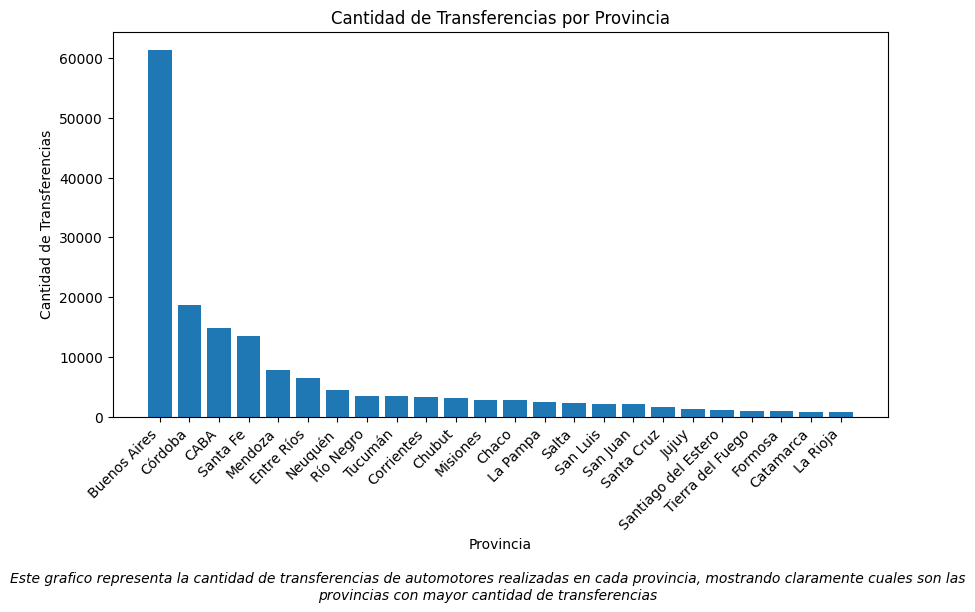

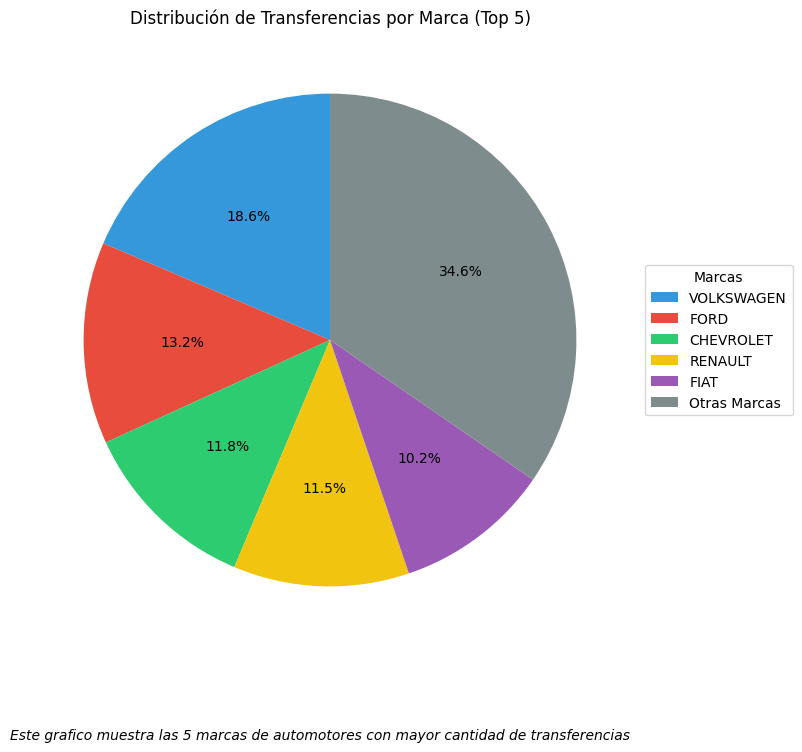

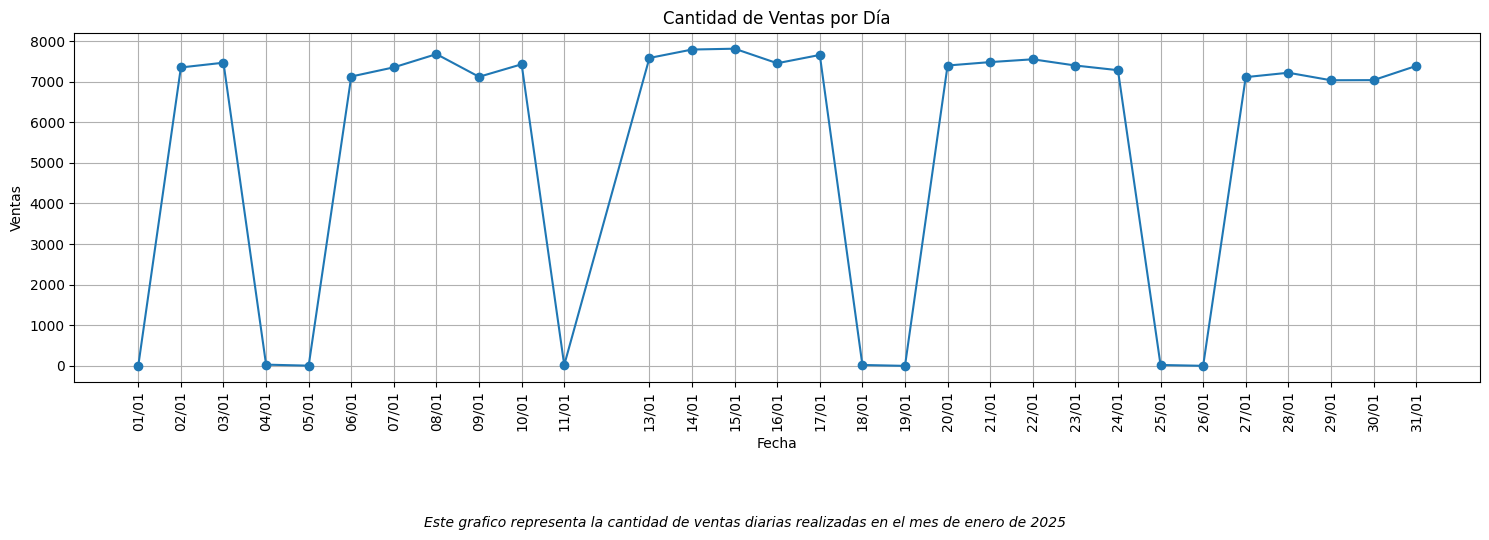

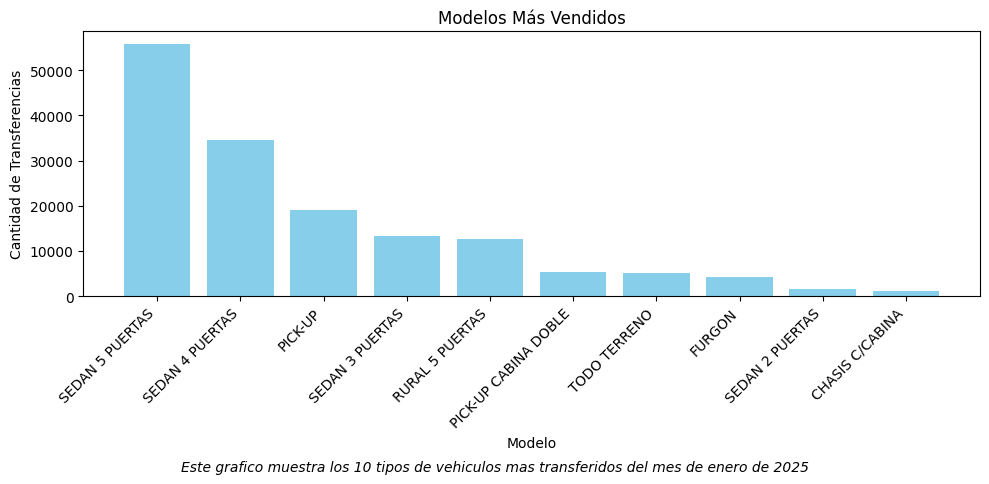

<Figure size 1000x500 with 0 Axes>

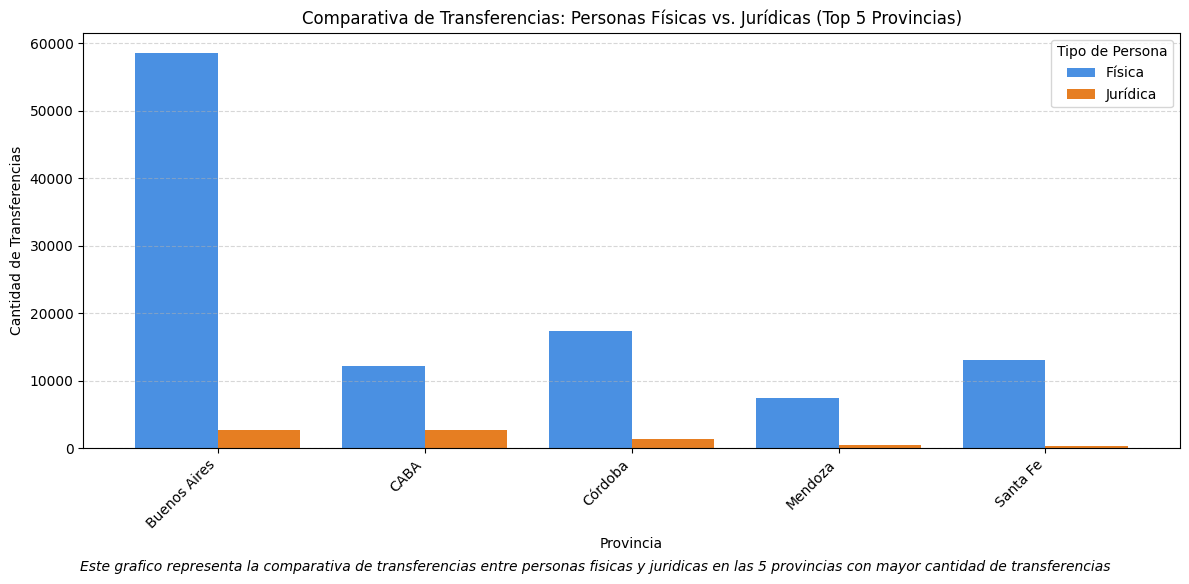

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


## Grafico de cantidad de transferencias por provincia
plt.figure(figsize=(10, 5))

conteo_provincias = df_csv_filtrado['registro_seccional_provincia'].value_counts()

plt.bar(conteo_provincias.index.str.replace('Ciudad Autónoma de Buenos Aires', 'CABA'), conteo_provincias.values)
plt.title('Cantidad de Transferencias por Provincia')
plt.xlabel('Provincia')
plt.ylabel('Cantidad de Transferencias')
plt.xticks(rotation=45, ha='right')
plt.suptitle('Este grafico representa la cantidad de transferencias de automotores realizadas en cada provincia, mostrando claramente cuales son las provincias con mayor cantidad de transferencias', x=0.5, y=-0.2, wrap=True, fontsize=10, fontstyle='italic', fontweight='normal')

plt.show()

## Grafico de distribucion de transferencias por marca
plt.figure(figsize=(8, 8))

top_5 = df_csv_filtrado['automotor_marca_descripcion'].value_counts().head(5)
total_transferencias = df_csv_filtrado['automotor_marca_descripcion'].value_counts().sum()
total_otros = total_transferencias - top_5.sum()

otras_marcas = pd.Series([total_otros], index=['Otras Marcas'])
conteo_marcas = pd.concat([top_5, otras_marcas])

porciones =plt.pie(
    conteo_marcas.values,     
    autopct='%1.1f%%',             
    startangle=90,                 
    colors=['#3498db', '#e74c3c', '#2ecc71', '#f1c40f', '#9b59b6', '#7f8c8d'] 
)

plt.legend(
    porciones[0], 
    conteo_marcas.index, 
    title="Marcas", 
    loc="center left", 
    bbox_to_anchor=(1, 0.5)
)

plt.title('Distribución de Transferencias por Marca (Top 5)')
plt.suptitle('Este grafico muestra las 5 marcas de automotores con mayor cantidad de transferencias', x=0.5, y=0.01, wrap=True, fontsize=10, fontstyle='italic', fontweight='normal')

## Grafico de cantidad de transferencias por tipo de persona
plt.show()

plt.figure(figsize=(10, 5))

df_csv_filtrado['tramite_fecha'] = pd.to_datetime(df_csv_filtrado['tramite_fecha'])
ventas_por_dia = df_csv_filtrado.groupby(df_csv_filtrado['tramite_fecha'].dt.date).size()

ventas_por_dia.plot(kind='line', marker='o', figsize=(15, 5), grid=True)

plt.xticks(ticks=ventas_por_dia.index, labels=[d.strftime('%d/%m') for d in ventas_por_dia.index], rotation=90)

plt.title('Cantidad de Ventas por Día')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.suptitle('Este grafico representa la cantidad de ventas diarias realizadas en el mes de enero de 2025', x=0.5, y=-0.1, wrap=True, fontsize=10, fontstyle='italic', fontweight='normal')
plt.tight_layout()
plt.show()

## Grafico de los 10 modelos mas vendidos
plt.figure(figsize=(10, 5))
modelos_mas_vendidos = df_csv_filtrado['automotor_tipo_descripcion'].value_counts().head(10)
plt.bar(modelos_mas_vendidos.index, modelos_mas_vendidos.values, color='skyblue')
plt.title('Modelos Más Vendidos')
plt.xlabel('Modelo')
plt.ylabel('Cantidad de Transferencias')
plt.xticks(rotation=45, ha='right')
plt.suptitle('Este grafico muestra los 10 tipos de vehiculos mas transferidos del mes de enero de 2025', x=0.5, y=0.01, wrap=True, fontsize=10, fontstyle='italic', fontweight='normal')
plt.tight_layout()
plt.show()

## Grafico comparativo entre personas fisicas y juridicas en las 5 provincias con mayor cantidad de transferencias
plt.figure(figsize=(10, 5))
top_provincias = df_csv_filtrado['registro_seccional_provincia'].value_counts().head(5).index
datos_agrupados = df_csv_filtrado[df_csv_filtrado['registro_seccional_provincia'].isin(top_provincias)].groupby(['registro_seccional_provincia', 'titular_tipo_persona']).size().unstack(fill_value=0)
datos_agrupados.index = datos_agrupados.index.str.replace('Ciudad Autónoma de Buenos Aires', 'CABA')
datos_agrupados.plot(kind='bar', figsize=(12, 6), width=0.8, color=['#4a90e2', '#e67e22'])

plt.title('Comparativa de Transferencias: Personas Físicas vs. Jurídicas (Top 5 Provincias)')
plt.xlabel('Provincia')
plt.ylabel('Cantidad de Transferencias')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Tipo de Persona', loc='upper right')
plt.suptitle('Este grafico representa la comparativa de transferencias entre personas fisicas y juridicas en las 5 provincias con mayor cantidad de transferencias', x=0.5, y=0.01, wrap=True, fontsize=10, fontstyle='italic', fontweight='normal')

plt.tight_layout()
plt.show()


# Aqui generamos un nuevo csv con todos los datos ya limpios (queda comentado para no generar uno nuevo cada vez que se ejecute o por si acaso)
#df_csv_filtrado.to_csv('tranferencias_autos_limpio.csv', index=False)

# Aqui generamos otro csv pero esta vez solo con el 10% de las filas, distribuidas entre todos los dias, exclusivamente para subir a Grafana y poder realizar los graficos
df_csv_filtrado['tramite_fecha'] = df_csv_filtrado['tramite_fecha'].astype(str)
df_reducido = df_csv_filtrado.groupby('tramite_fecha', group_keys=False).apply(
    lambda x: x.sample(frac=0.10, random_state=42)
)
df_reducido.to_csv('tranferencias_autos_mini.csv', index=False)